# Notebook 02 — Data Exploration

## Data-Driven Framework for Early Detection of Alzheimer's Disease Using MRI Brain Images

---

### What This Notebook Does
This notebook performs a **deep visual exploration** of the OASIS MRI dataset:
1. Display sample images from each class in a grid
2. Analyze image dimensions and file sizes
3. Compute pixel intensity distributions per class
4. Show class imbalance with detailed visualizations
5. Print comprehensive dataset statistics

### What You Should Check After Running
- Do the MRI images look correct (brain scans, not corrupted)?
- Can you visually distinguish differences between classes?
- Is the pixel intensity distribution different across classes?

### Next Notebook
`03_data_preprocessing.ipynb` — We will prepare the data for model training (resize, normalize, split, augment).

## 1. Setup & Imports

In [1]:
# ============================================================
# Imports
# ============================================================
import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# ============================================================
# Style settings
# ============================================================
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Reproducibility
random.seed(42)
np.random.seed(42)

# ============================================================
# Dataset paths
# ============================================================
DATA_DIR = Path("Data")
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

# Color palette for consistent class colors throughout the notebook
CLASS_COLORS = {
    'Mild Dementia': '#e74c3c',
    'Moderate Dementia': '#9b59b6',
    'Non Demented': '#2ecc71',
    'Very mild Dementia': '#f39c12'
}

print(f"Classes: {CLASS_NAMES}")
print("Setup complete!")

Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Setup complete!


## 2. Helper Functions

We define reusable functions to load image paths and display grids.

In [2]:
def get_image_paths(class_name):
    """Get all valid image file paths for a given class."""
    class_dir = DATA_DIR / class_name
    return sorted([
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    ])


def load_image(path):
    """Load an image and convert to RGB (handles grayscale images)."""
    img = Image.open(path).convert('RGB')
    return img


# Build a dictionary of all image paths per class
all_image_paths = {}
for cls in CLASS_NAMES:
    paths = get_image_paths(cls)
    all_image_paths[cls] = paths
    print(f"{cls}: {len(paths):,} images")

total = sum(len(v) for v in all_image_paths.values())
print(f"\nTotal: {total:,} images")

Mild Dementia: 5,002 images
Moderate Dementia: 488 images
Non Demented: 1,745 images
Very mild Dementia: 13,725 images

Total: 20,960 images


## 3. Visualize Sample Images

### 3.1 Sample Grid — 5 Random Images Per Class

This gives us an intuitive feel for what MRI images look like across different dementia stages. We display **5 random images** from each of the 4 classes (20 images total).

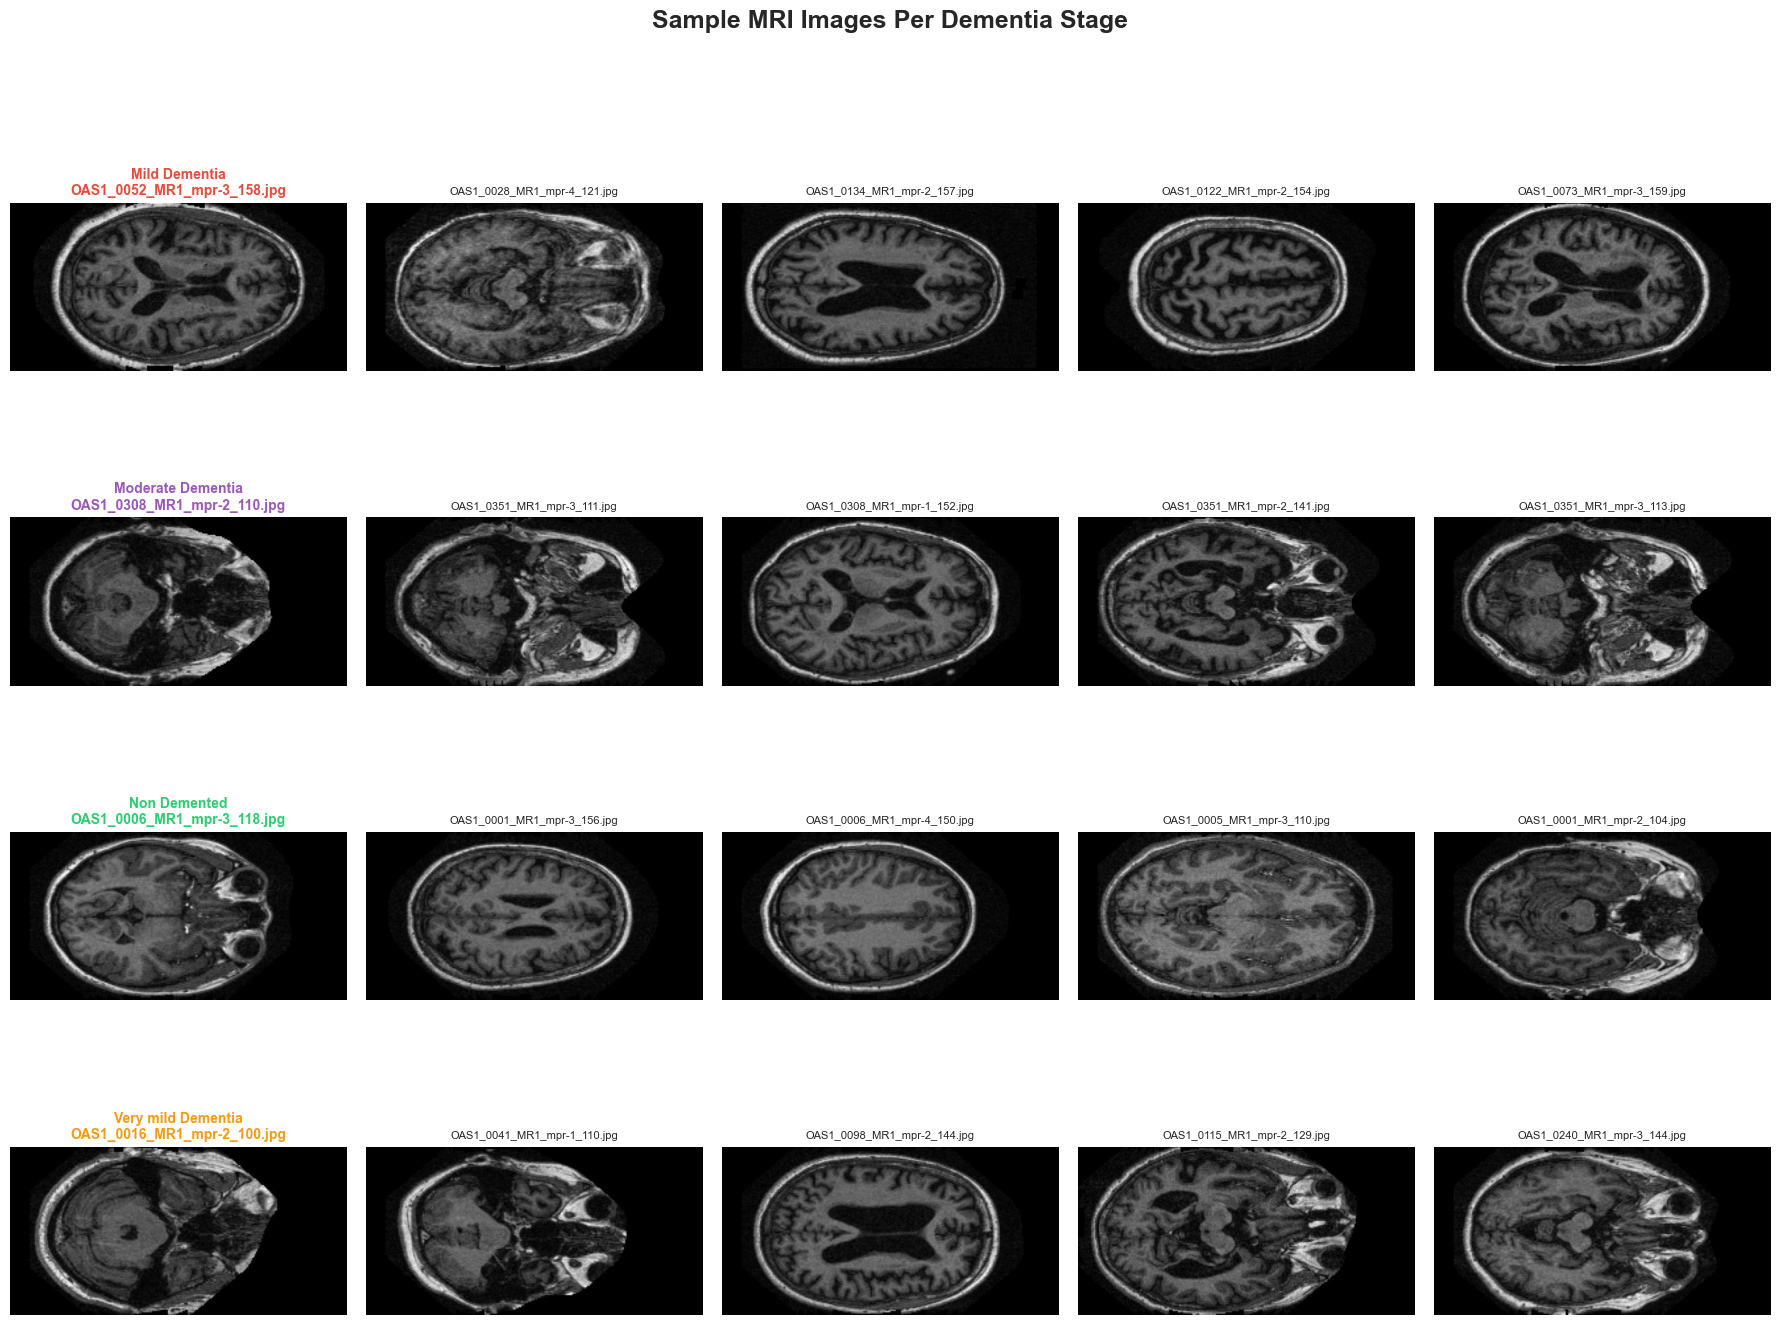

Saved as 'sample_images_grid.png'


In [3]:
# ============================================================
# Display a grid: 4 rows (one per class) × 5 columns (samples)
# ============================================================
NUM_SAMPLES = 5

fig, axes = plt.subplots(4, NUM_SAMPLES, figsize=(18, 14))
fig.suptitle('Sample MRI Images Per Dementia Stage', fontsize=18, fontweight='bold', y=1.02)

for row, class_name in enumerate(CLASS_NAMES):
    # Randomly sample images
    sampled_paths = random.sample(all_image_paths[class_name], 
                                  min(NUM_SAMPLES, len(all_image_paths[class_name])))
    
    for col, img_path in enumerate(sampled_paths):
        img = load_image(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        
        # Add filename as subtitle
        if col == 0:
            axes[row, col].set_title(f"{class_name}\n{img_path.name}", 
                                     fontsize=10, fontweight='bold',
                                     color=CLASS_COLORS.get(class_name, 'black'))
        else:
            axes[row, col].set_title(img_path.name, fontsize=8)

plt.tight_layout()
plt.savefig('sample_images_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'sample_images_grid.png'")

### 3.2 Side-by-Side Comparison — One Image Per Class

A clearer comparison showing one representative image from each class at a larger scale.

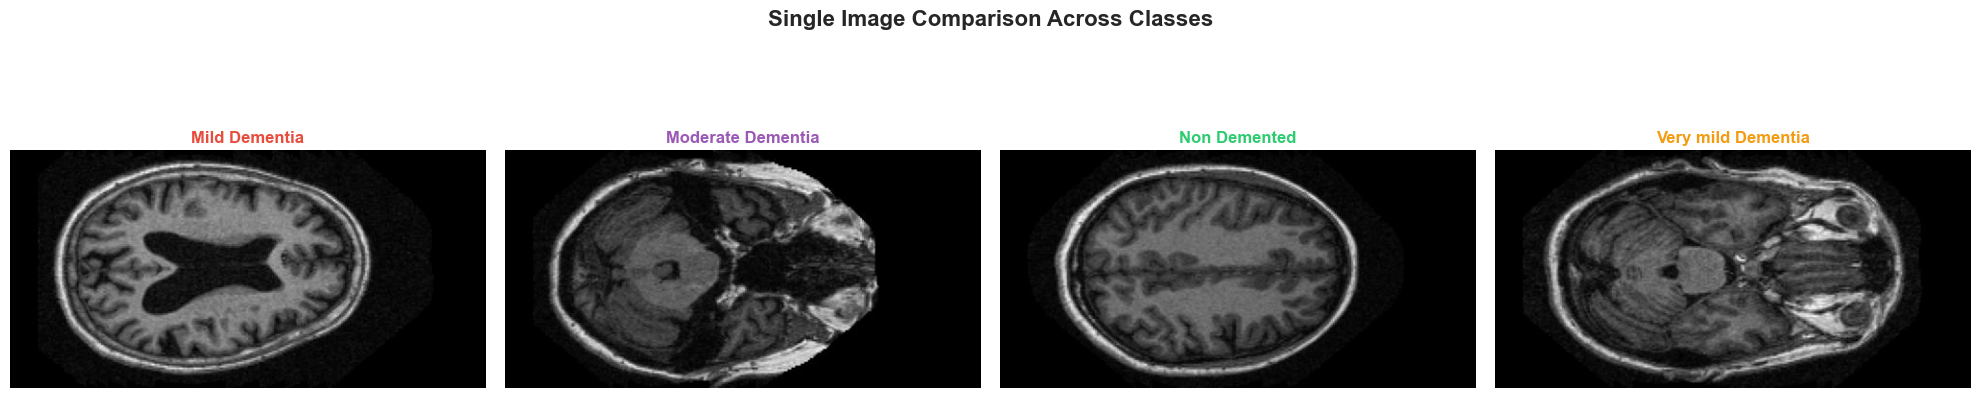

In [4]:
# ============================================================
# One large image per class for easy comparison
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Single Image Comparison Across Classes', fontsize=16, fontweight='bold')

for idx, class_name in enumerate(CLASS_NAMES):
    img_path = random.choice(all_image_paths[class_name])
    img = load_image(img_path)
    
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=12, fontweight='bold',
                        color=CLASS_COLORS.get(class_name, 'black'))
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Image Dimension & File Size Analysis

Let's check if all images have the same dimensions and analyze file sizes. This is important for:
- Deciding if resizing is needed
- Understanding the data quality
- Estimating memory requirements

In [5]:
# ============================================================
# Collect dimensions and file sizes for ALL images
# This may take a minute for ~13K images
# ============================================================
image_info = []  # (class_name, width, height, file_size_kb, mode)

print("Scanning all images (this may take 1-2 minutes)...")
for class_name in CLASS_NAMES:
    for img_path in tqdm(all_image_paths[class_name], desc=class_name, leave=True):
        try:
            img = Image.open(img_path)
            w, h = img.size
            mode = img.mode
            file_size = img_path.stat().st_size / 1024  # KB
            image_info.append((class_name, w, h, file_size, mode))
            img.close()
        except Exception as e:
            print(f"  ⚠️ Error reading {img_path.name}: {e}")

print(f"\nSuccessfully scanned {len(image_info):,} images.")

Scanning all images (this may take 1-2 minutes)...


Very mild Dementia: 100%|██████████| 13725/13725 [03:17<00:00, 69.45it/s] 


Successfully scanned 20,960 images.


In [6]:
# ============================================================
# Summarize dimensions
# ============================================================
widths = [info[1] for info in image_info]
heights = [info[2] for info in image_info]
file_sizes = [info[3] for info in image_info]
modes = Counter([info[4] for info in image_info])
dimensions = Counter([(info[1], info[2]) for info in image_info])

print("=" * 60)
print("IMAGE DIMENSION STATISTICS")
print("=" * 60)
print(f"Unique dimensions: {len(dimensions)}")
for dim, count in dimensions.most_common(10):
    print(f"  {dim[0]}×{dim[1]}: {count:,} images ({count/len(image_info)*100:.1f}%)")

print(f"\nWidth  — Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}")
print(f"Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}")

print(f"\nColor modes: {dict(modes)}")

print(f"\nFILE SIZE STATISTICS")
print(f"Min:    {min(file_sizes):.1f} KB")
print(f"Max:    {max(file_sizes):.1f} KB")
print(f"Mean:   {np.mean(file_sizes):.1f} KB")
print(f"Median: {np.median(file_sizes):.1f} KB")
print(f"Total:  {sum(file_sizes)/1024:.1f} MB")

IMAGE DIMENSION STATISTICS
Unique dimensions: 1
  496×248: 20,960 images (100.0%)

Width  — Min: 496, Max: 496, Mean: 496
Height — Min: 248, Max: 248, Mean: 248

Color modes: {'RGB': 20960}

FILE SIZE STATISTICS
Min:    7.9 KB
Max:    21.3 KB
Mean:   15.3 KB
Median: 15.4 KB
Total:  313.7 MB


C:\Users\Karan Banerjee\AppData\Local\Temp\ipykernel_154496\3347870138.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=CLASS_NAMES, patch_artist=True)


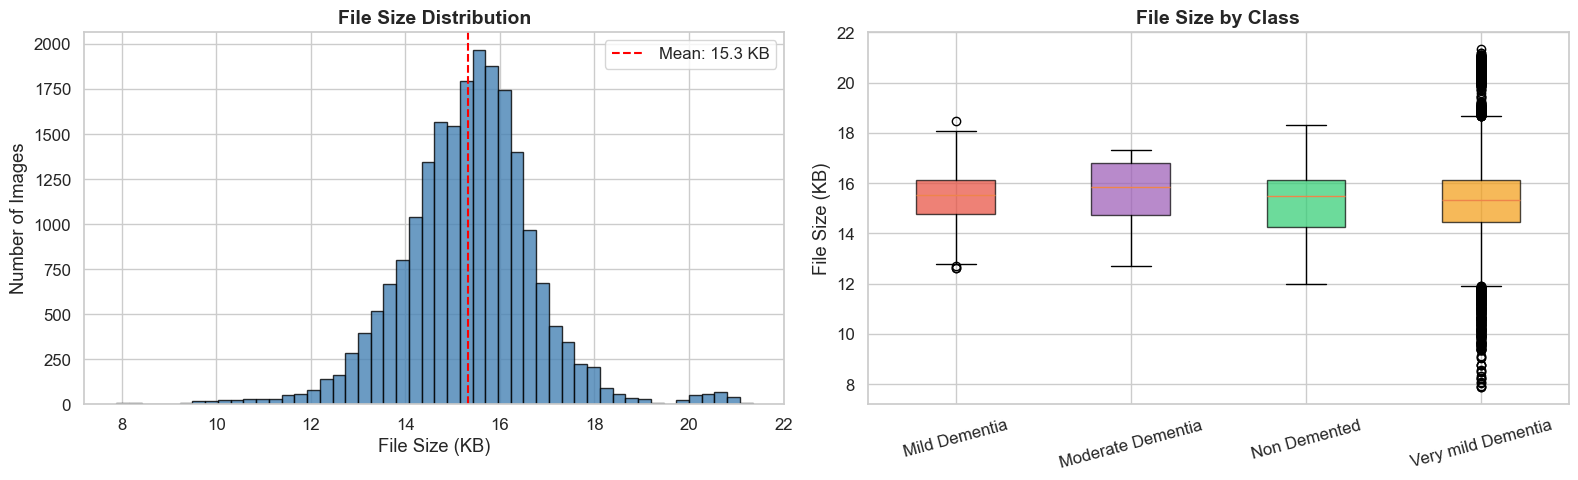

In [7]:
# ============================================================
# Plot file size distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# File size histogram
axes[0].hist(file_sizes, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('File Size Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('File Size (KB)')
axes[0].set_ylabel('Number of Images')
axes[0].axvline(np.mean(file_sizes), color='red', linestyle='--', label=f'Mean: {np.mean(file_sizes):.1f} KB')
axes[0].legend()

# File size per class (box plot)
class_file_sizes = {cls: [] for cls in CLASS_NAMES}
for info in image_info:
    class_file_sizes[info[0]].append(info[3])

box_data = [class_file_sizes[cls] for cls in CLASS_NAMES]
bp = axes[1].boxplot(box_data, labels=CLASS_NAMES, patch_artist=True)
for patch, cls in zip(bp['boxes'], CLASS_NAMES):
    patch.set_facecolor(CLASS_COLORS.get(cls, 'steelblue'))
    patch.set_alpha(0.7)
axes[1].set_title('File Size by Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('File Size (KB)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 5. Pixel Intensity Analysis

Pixel intensity distributions can reveal differences between classes that the model might learn. Brighter regions typically indicate different brain tissue density.

### Why This Matters
- **Alzheimer's causes brain atrophy** (tissue loss), which shows as darker regions in MRI
- Different dementia stages may have subtly different intensity distributions
- This helps us understand what visual features the model will need to learn

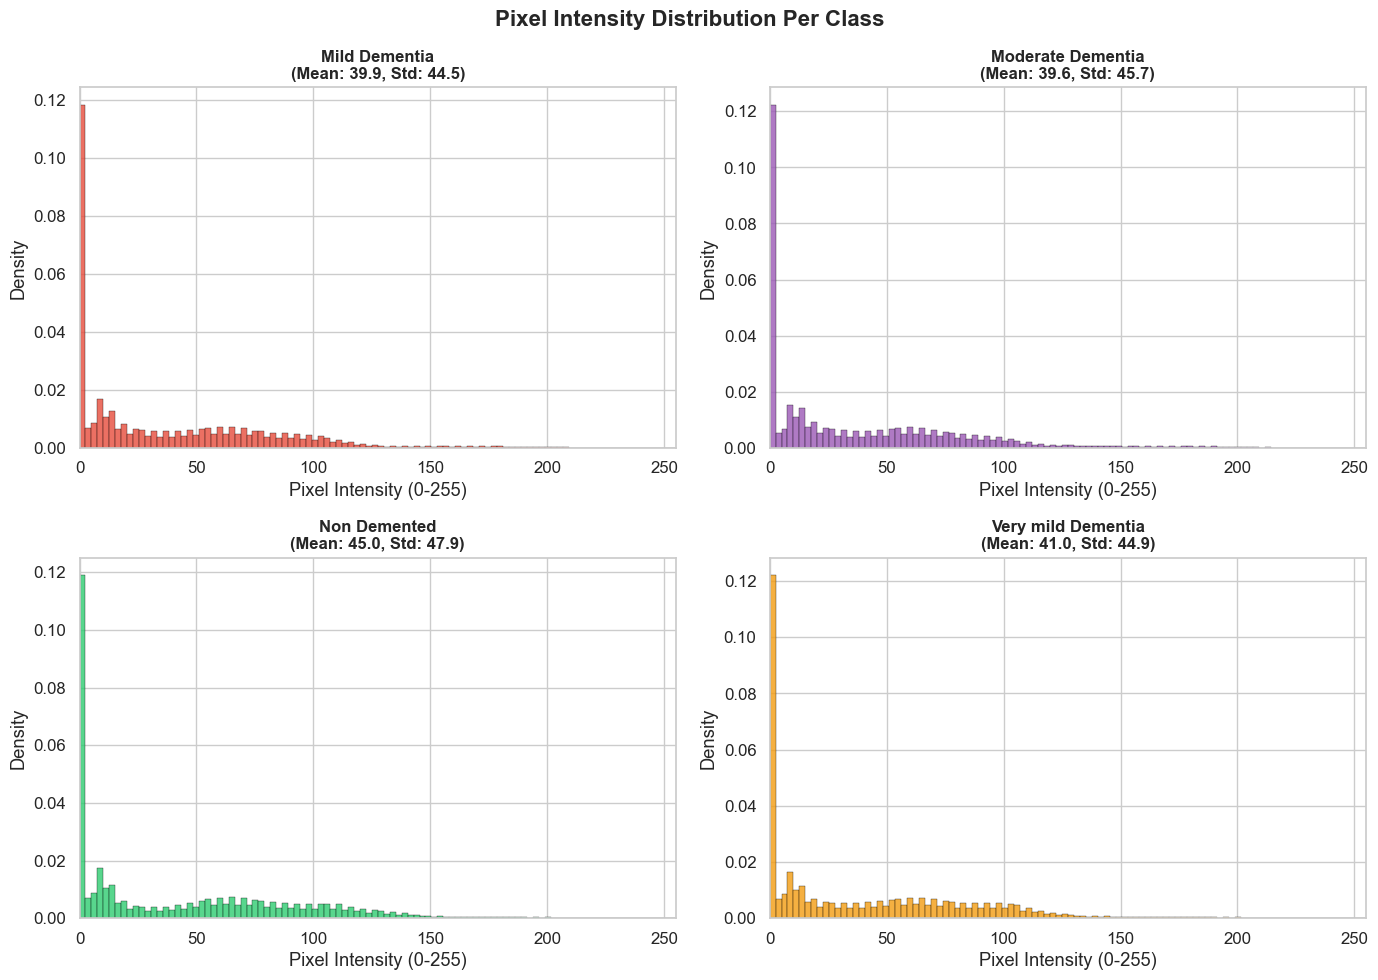

Saved as 'pixel_intensity_distributions.png'


In [8]:
# ============================================================
# Compute pixel intensity distribution per class
# We sample images for speed (50 per class)
# ============================================================
INTENSITY_SAMPLES = 50

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pixel Intensity Distribution Per Class', fontsize=16, fontweight='bold')

class_means = {}  # Store mean intensity per class

for idx, class_name in enumerate(CLASS_NAMES):
    ax = axes[idx // 2, idx % 2]
    
    # Sample images
    sampled = random.sample(all_image_paths[class_name],
                            min(INTENSITY_SAMPLES, len(all_image_paths[class_name])))
    
    # Compute pixel values
    all_pixels = []
    for img_path in sampled:
        img = load_image(img_path)
        img_array = np.array(img).flatten()
        all_pixels.extend(img_array)
    
    all_pixels = np.array(all_pixels)
    class_means[class_name] = np.mean(all_pixels)
    
    # Plot histogram
    ax.hist(all_pixels, bins=100, color=CLASS_COLORS.get(class_name, 'steelblue'), 
            alpha=0.8, edgecolor='black', linewidth=0.3, density=True)
    ax.set_title(f"{class_name}\n(Mean: {np.mean(all_pixels):.1f}, Std: {np.std(all_pixels):.1f})",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel Intensity (0-255)')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 255)

plt.tight_layout()
plt.savefig('pixel_intensity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'pixel_intensity_distributions.png'")

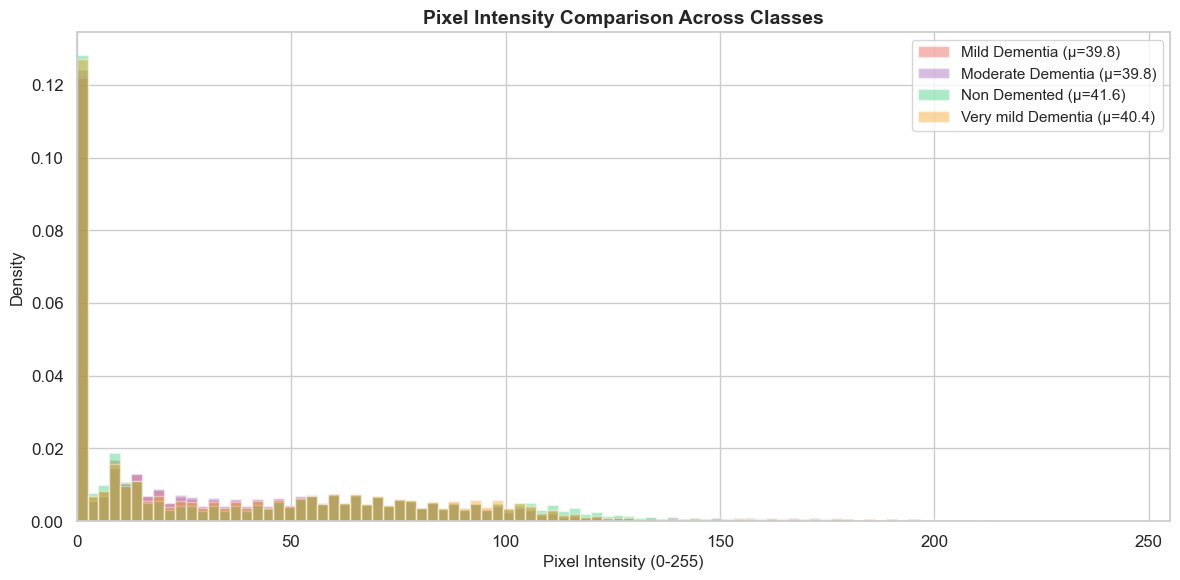

In [9]:
# ============================================================
# Overlay intensity distributions for direct comparison
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

for class_name in CLASS_NAMES:
    sampled = random.sample(all_image_paths[class_name],
                            min(INTENSITY_SAMPLES, len(all_image_paths[class_name])))
    
    all_pixels = []
    for img_path in sampled:
        img = load_image(img_path)
        all_pixels.extend(np.array(img).flatten())
    
    ax.hist(all_pixels, bins=100, alpha=0.4, density=True, 
            label=f"{class_name} (μ={np.mean(all_pixels):.1f})",
            color=CLASS_COLORS.get(class_name, None))

ax.set_title('Pixel Intensity Comparison Across Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('Pixel Intensity (0-255)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()

## 6. Class Imbalance — Detailed Visualization

We already saw the imbalance in Notebook 01. Here we add more detail to emphasize the severity.

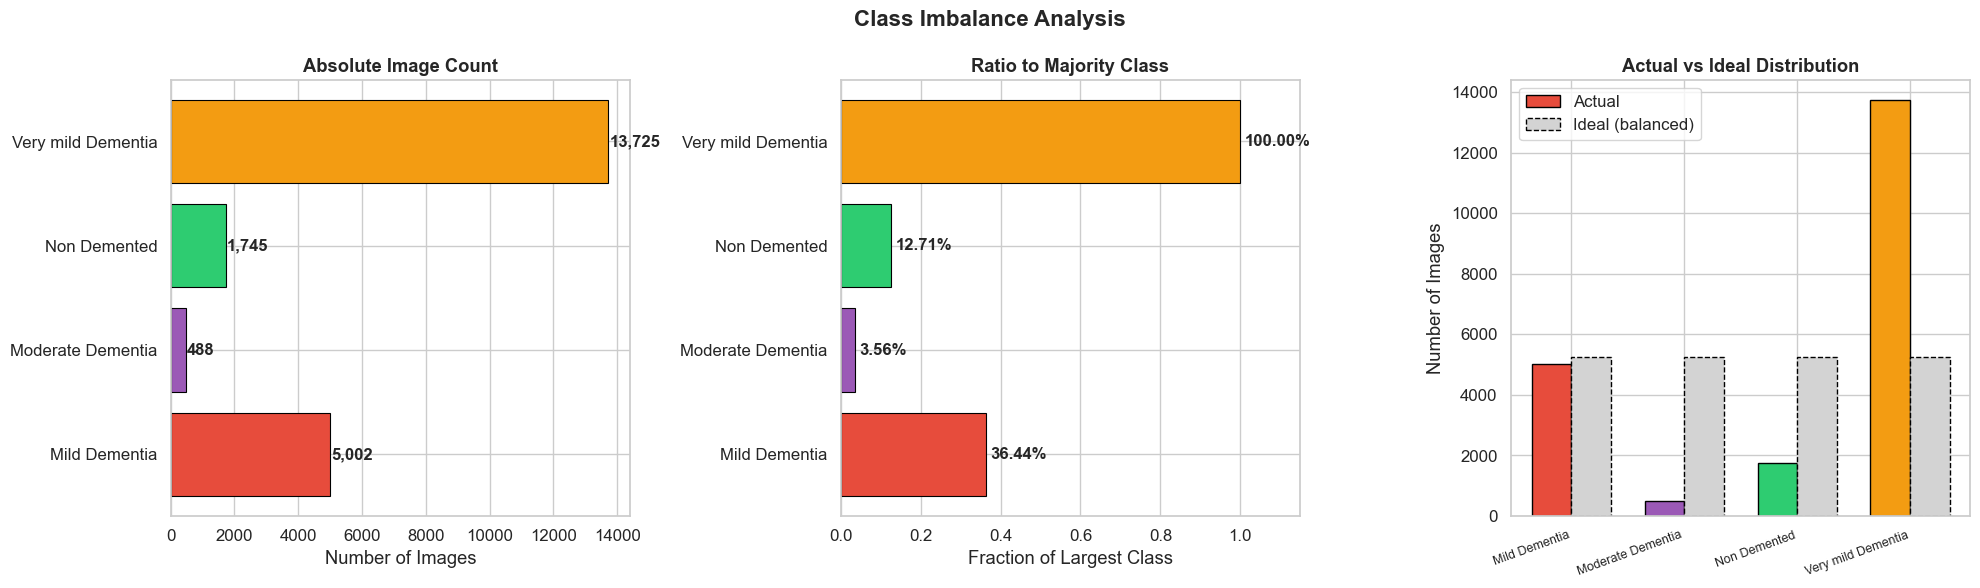

Saved as 'class_imbalance_analysis.png'


In [10]:
# ============================================================
# Detailed imbalance visualization
# ============================================================
class_counts = {cls: len(all_image_paths[cls]) for cls in CLASS_NAMES}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Class Imbalance Analysis', fontsize=16, fontweight='bold')

# --- 1. Absolute counts ---
bars = axes[0].barh(list(class_counts.keys()), list(class_counts.values()),
                     color=[CLASS_COLORS[c] for c in class_counts.keys()],
                     edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, class_counts.values()):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                f'{count:,}', va='center', fontweight='bold', fontsize=12)
axes[0].set_title('Absolute Image Count', fontweight='bold')
axes[0].set_xlabel('Number of Images')

# --- 2. Ratio relative to majority class ---
max_count = max(class_counts.values())
ratios = {cls: cnt/max_count for cls, cnt in class_counts.items()}
axes[1].barh(list(ratios.keys()), list(ratios.values()),
              color=[CLASS_COLORS[c] for c in ratios.keys()],
              edgecolor='black', linewidth=0.8)
for bar, ratio in zip(axes[1].patches, ratios.values()):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{ratio:.2%}', va='center', fontweight='bold', fontsize=12)
axes[1].set_title('Ratio to Majority Class', fontweight='bold')
axes[1].set_xlabel('Fraction of Largest Class')
axes[1].set_xlim(0, 1.15)

# --- 3. Ideal vs Actual distribution ---
total = sum(class_counts.values())
ideal_count = total / 4  # If perfectly balanced

x = np.arange(len(CLASS_NAMES))
width = 0.35

actual_vals = [class_counts[c] for c in CLASS_NAMES]
ideal_vals = [ideal_count] * 4

axes[2].bar(x - width/2, actual_vals, width, label='Actual',
            color=[CLASS_COLORS[c] for c in CLASS_NAMES], edgecolor='black')
axes[2].bar(x + width/2, ideal_vals, width, label='Ideal (balanced)',
            color='lightgray', edgecolor='black', linestyle='--')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=9)
axes[2].set_title('Actual vs Ideal Distribution', fontweight='bold')
axes[2].set_ylabel('Number of Images')
axes[2].legend()

plt.tight_layout()
plt.savefig('class_imbalance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'class_imbalance_analysis.png'")

## 7. Mean Image Per Class

By averaging all images in a class, we can see the **typical pattern** for each dementia stage. Differences in the mean image highlight the brain regions that vary most between classes.

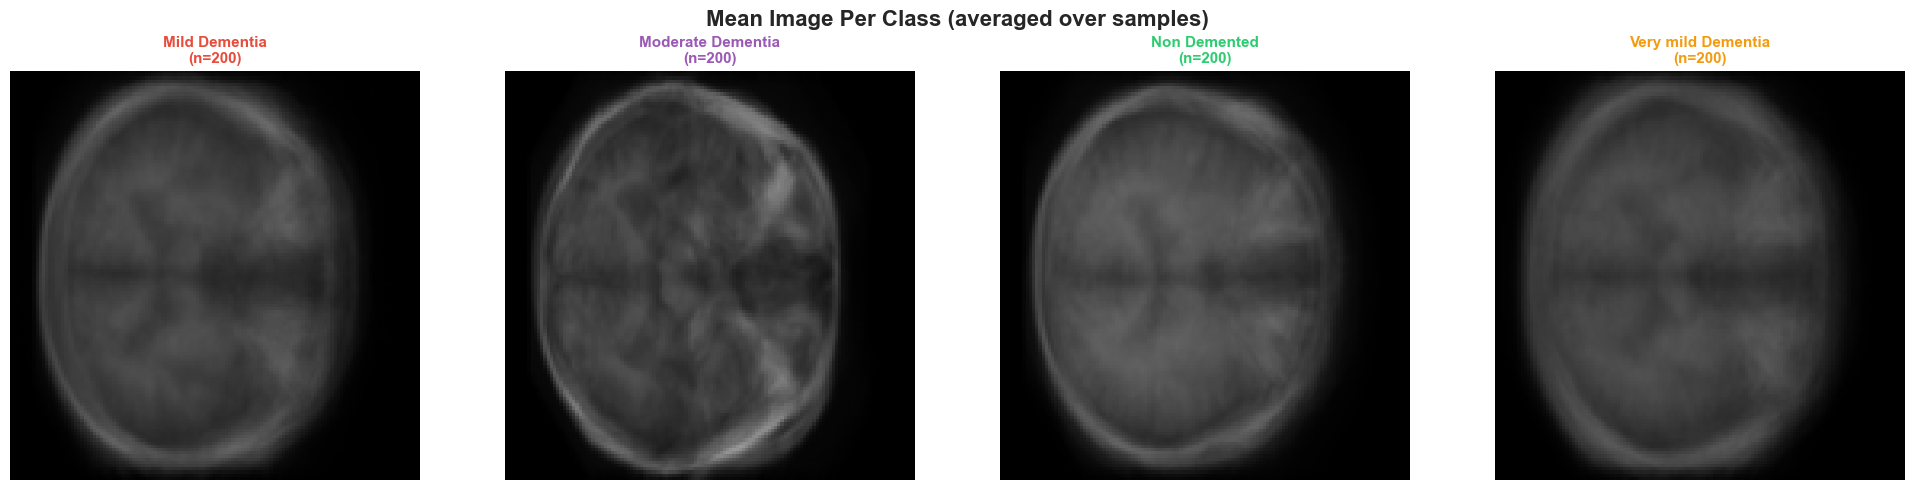

Saved as 'mean_images_per_class.png'


In [11]:
# ============================================================
# Compute mean image per class
# We resize all images to a common size before averaging
# ============================================================
TARGET_SIZE = (128, 128)  # Resize for consistency
MEAN_SAMPLES = 200  # Use up to 200 images per class

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Mean Image Per Class (averaged over samples)', fontsize=16, fontweight='bold')

for idx, class_name in enumerate(CLASS_NAMES):
    sampled = random.sample(all_image_paths[class_name],
                            min(MEAN_SAMPLES, len(all_image_paths[class_name])))
    
    # Accumulate pixel values
    accumulator = np.zeros((*TARGET_SIZE, 3), dtype=np.float64)
    for img_path in sampled:
        img = load_image(img_path).resize(TARGET_SIZE)
        accumulator += np.array(img, dtype=np.float64)
    
    mean_img = (accumulator / len(sampled)).astype(np.uint8)
    
    axes[idx].imshow(mean_img)
    axes[idx].set_title(f"{class_name}\n(n={len(sampled)})", fontsize=11, fontweight='bold',
                        color=CLASS_COLORS.get(class_name, 'black'))
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('mean_images_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'mean_images_per_class.png'")

## 8. Channel Analysis (RGB)

Even though MRI scans are inherently grayscale, the images in this dataset are stored as RGB. Let's verify whether the R, G, B channels are identical (true grayscale) or if there's any color information.

In [12]:
# ============================================================
# Check if R, G, B channels are identical across sample images
# ============================================================
n_check = 20  # Check 20 random images
all_paths_flat = [p for cls in CLASS_NAMES for p in all_image_paths[cls]]
check_paths = random.sample(all_paths_flat, min(n_check, len(all_paths_flat)))

channels_identical = True
for img_path in check_paths:
    img = np.array(load_image(img_path))
    if not (np.array_equal(img[:,:,0], img[:,:,1]) and np.array_equal(img[:,:,1], img[:,:,2])):
        channels_identical = False
        break

if channels_identical:
    print("✅ All R, G, B channels are IDENTICAL across sampled images.")
    print("   → Images are stored as RGB but are effectively grayscale.")
    print("   → We will still use 3-channel input for compatibility with pretrained models.")
else:
    print("ℹ️ Some images have different R, G, B channels.")
    print("   → Images may contain color information. Using RGB.")

✅ All R, G, B channels are IDENTICAL across sampled images.
   → Images are stored as RGB but are effectively grayscale.
   → We will still use 3-channel input for compatibility with pretrained models.


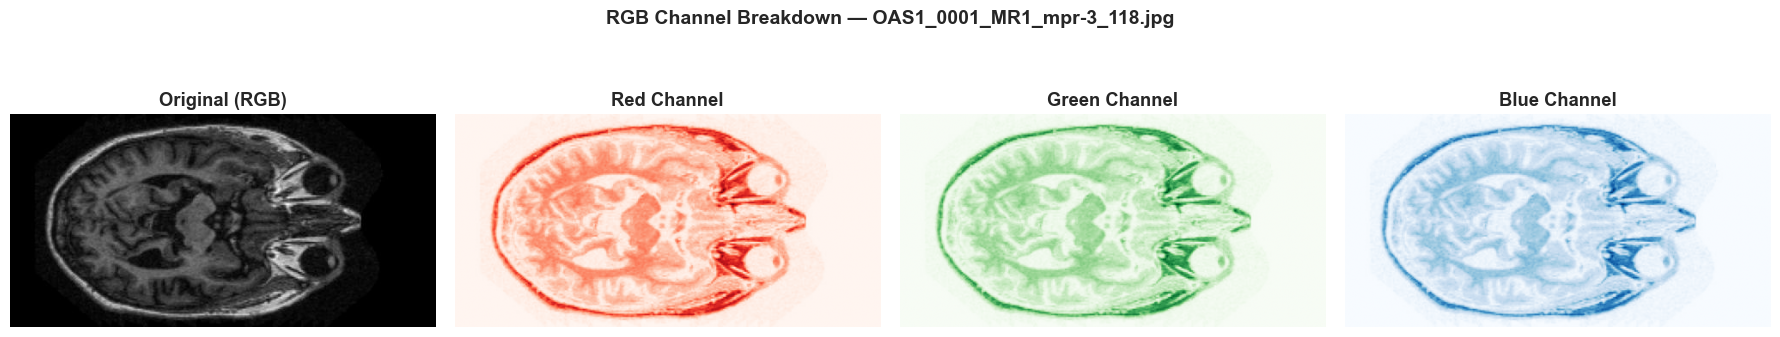

In [13]:
# ============================================================
# Visualize individual RGB channels for one sample image
# ============================================================
sample_path = random.choice(all_image_paths['Non Demented'])
sample_img = np.array(load_image(sample_path))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f'RGB Channel Breakdown — {sample_path.name}', fontsize=14, fontweight='bold')

# Original
axes[0].imshow(sample_img)
axes[0].set_title('Original (RGB)', fontweight='bold')
axes[0].axis('off')

# Individual channels
channel_names = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']
for i in range(3):
    axes[i+1].imshow(sample_img[:,:,i], cmap=cmaps[i])
    axes[i+1].set_title(f'{channel_names[i]} Channel', fontweight='bold')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

## 9. Dataset Statistics Summary

In [14]:
# ============================================================
# Comprehensive dataset summary table
# ============================================================
total_images = sum(class_counts.values())
total_size_mb = sum(file_sizes) / 1024

print("╔" + "═" * 58 + "╗")
print("║" + " DATASET SUMMARY".center(58) + "║")
print("╠" + "═" * 58 + "╣")
print(f"║  Dataset:            Kaggle OASIS MRI Dataset{' ':>12}║")
print(f"║  Total images:       {total_images:>6,}{' ':>30}║")
print(f"║  Total size:         {total_size_mb:>6.1f} MB{' ':>27}║")
print(f"║  Number of classes:  {len(CLASS_NAMES):>6}{' ':>30}║")
print(f"║  Image format:       JPEG (RGB){' ':>25}║")
print(f"║  Unique dimensions:  {len(dimensions):>6}{' ':>30}║")
print("╠" + "═" * 58 + "╣")
print("║" + " CLASS BREAKDOWN".center(58) + "║")
print("╠" + "═" * 58 + "╣")
for cls in CLASS_NAMES:
    cnt = class_counts[cls]
    pct = cnt / total_images * 100
    line = f"  {cls:<25} {cnt:>6,} ({pct:>5.1f}%)"
    print(f"║{line:<58}║")
print("╠" + "═" * 58 + "╣")
max_cls = max(class_counts, key=class_counts.get)
min_cls = min(class_counts, key=class_counts.get)
ratio = class_counts[max_cls] / class_counts[min_cls]
print(f"║  Imbalance ratio:    {ratio:>6.1f}:1{' ':>28}║")
print(f"║  Majority class:     {max_cls:<35}║")
print(f"║  Minority class:     {min_cls:<35}║")
print("╚" + "═" * 58 + "╝")

╔══════════════════════════════════════════════════════════╗
║                      DATASET SUMMARY                     ║
╠══════════════════════════════════════════════════════════╣
║  Dataset:            Kaggle OASIS MRI Dataset            ║
║  Total images:       20,960                              ║
║  Total size:          313.7 MB                           ║
║  Number of classes:       4                              ║
║  Image format:       JPEG (RGB)                         ║
║  Unique dimensions:       1                              ║
╠══════════════════════════════════════════════════════════╣
║                      CLASS BREAKDOWN                     ║
╠══════════════════════════════════════════════════════════╣
║  Mild Dementia              5,002 ( 23.9%)               ║
║  Moderate Dementia            488 (  2.3%)               ║
║  Non Demented               1,745 (  8.3%)               ║
║  Very mild Dementia        13,725 ( 65.5%)               ║
╠════════════════════════

## 10. Key Observations

### Visual Observations
- MRI brain images show **axial cross-sections** of the brain
- Images are stored as RGB but are essentially **grayscale** (all 3 channels identical)
- Brain tissue appears as lighter regions; cerebrospinal fluid (CSF) and background are darker
- In advanced dementia stages, you may notice **enlarged ventricles** (dark regions in the center) and **reduced cortical thickness**

### Technical Observations
- All images appear to be JPEG format
- Images may or may not have consistent dimensions (verified above)
- The dataset has **extreme class imbalance** that we MUST handle
- File sizes are relatively small — the dataset can fit in RAM easily

### Implications for Preprocessing (Next Notebook)
1. **Resize** to 128×128 — reduces VRAM usage
2. **Keep RGB** (3 channels) — needed for pretrained model compatibility
3. **Normalize** with ImageNet statistics — required for transfer learning
4. **Augmentation** — especially important for minority classes
5. **Weighted sampling** — critical to address the 100:1 class imbalance

---

### Summary
- ✅ Images are valid MRI brain scans
- ✅ No corrupted files detected
- ✅ Class imbalance is severe and well-understood
- ✅ We know the image format and size characteristics

### Next Step
→ **Notebook 03** (`03_data_preprocessing.ipynb`): Resize, normalize, split into train/val/test, apply data augmentation, and create balanced DataLoaders.

---
*End of Notebook 02*